In [2]:
import sys
import os

# Option A: Use a relative path (e.g., up one directory level)
sys.path.insert(0, os.path.abspath('..'))

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray


In [18]:



from analysis.types import PositionsDict 
from analysis.extract import load_positions   
from analysis.types import PairDistanceData

In [ ]:



def compute_inter_distance_squared(trajectories: PositionsDict) -> float:
    """
    Computes the inter-distance between two points in a 2D space.
    
    Returns:
        float: The distance between the two points.
    """
    n = len(trajectories)
    trange = trajectories[list(trajectories.keys())[0]].shape[0]
    dro_ids = list(trajectories.keys())
    
    pair_map = []

    for i in range(n):
        for j in range(i+1,n):
            pair_map.append((dro_ids[i], dro_ids[j]))
    
    dij = np.zeros((trange, len(pair_map)))
    for t in range(trange):
        
        for k,(i,j) in enumerate(pair_map):
                    
            r1 = trajectories[i]
            r2 = trajectories[j]
            
            dr = r1[t] - r2[t]
            dij[t,k] = np.dot(dr, dr)
     
                
    return dij,pair_map




dis,pair = compute_inter_distance_squared(trajectories=trajectories)
p = PairDistanceData(dis,pair)


In [2]:
p.nframes

3951

In [3]:
from analysis.pairwise import compute_inter_distance_squared
from analysis.extract import load_positions   


In [4]:
trajectories,*_ = load_positions('../output_droplet_tracking/csv_files/for_2.3_droplets.csv')

p = compute_inter_distance_squared(trajectories=trajectories)

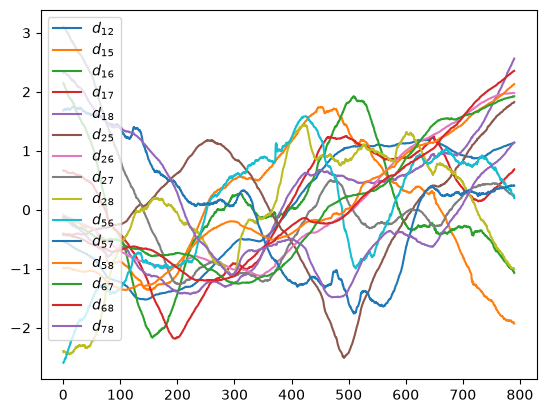

In [25]:
def dij_telda(dijs :PairDistanceData):
    
    m = np.zeros(shape=(dijs.nframes,dijs.npairs))
    
    for i in range(dijs.npairs):
        dij = dijs.distances[:,i]
        dij_mean = np.mean(dij)
        dij_std = np.std(dij)
        # dij_var = np.var(dij)
        m[:,i] = (dij - dij_mean)/dij_std
        
    return m 
        
        
dtelda = dij_telda(p)
        
t = [.2*i for i in range(p.nframes)]

for i in range(p.npairs):
    
    map = p.pair_map
    plt.plot(t,dtelda[:,i],
             label=fr'$d_{str(map[i][0])}$$_{str(map[i][1])}$')
    
    
plt.legend()
# .2*list(range(12))
    

mean = 251.23657181014667 varience = 17459.901019375033
mean = 324.06973191240127 varience = 3473.3712633114674
mean = 146.75399249158028 varience = 1653.2922691972528
mean = 191.3275427641535 varience = 5697.845851466438
mean = 264.84599667059996 varience = 5481.341766409459
mean = 209.70681110395512 varience = 5387.127308547634
mean = 203.73824536157676 varience = 20298.344524359058
mean = 153.13957426526804 varience = 2264.659940478609
mean = 155.7163155056618 varience = 726.7214991851024
mean = 214.5391042702803 varience = 832.8474203336292
mean = 235.92966068593418 varience = 989.6973175495378
mean = 206.05375156444467 varience = 12816.876575281454
mean = 160.2288798967737 varience = 8238.872369613066
mean = 222.39075122890122 varience = 19412.767612419033
mean = 134.19203849265543 varience = 5307.6212922083905


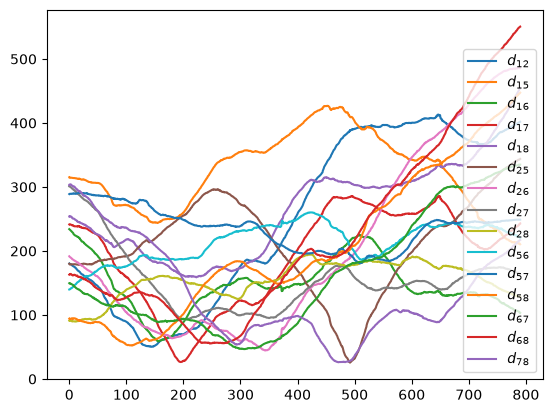

In [16]:
dij = p.distances[:,0]

t = [.2*i for i in range(p.nframes)]

for i in range(p.npairs):
    
    map = p.pair_map
    plt.plot(t,p.distances[:,i],
             label=fr'$d_{str(map[i][0])}$$_{str(map[i][1])}$')
    
        
    dij_mean = np.mean(p.distances[:,i])
    dij_var = np.var(p.distances[:,i])
    
    print("mean = "+ str(dij_mean)+" "+"varience = " + str(dij_var))
plt.legend()
# .2*list(range(12))

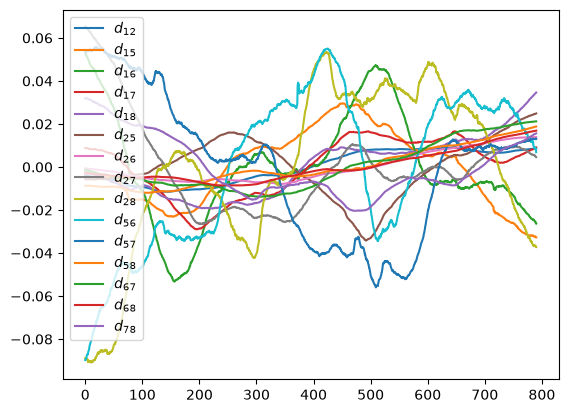